# NLP + LLM Practical Labs 8–11

This notebook is a complete hands-on guide for the topics shown in your syllabus image:

- **Lab 8:** NLP Pipeline — feature selection, encoding, scaling, TF-IDF, word embeddings, BERT intro, sentiment analysis
- **Lab 9:** LLM API Explorer — tokens, temperature, context window, embedding similarity, cosine/dot similarity
- **Lab 10:** Prompt Library — zero-shot, few-shot, chain-of-thought style prompting, system prompts, JSON output, hallucination mitigation
- **Lab 11:** PDF Q&A Bot — RAG architecture, chunking, FAISS, ChromaDB concept, top-k similarity search, LLM synthesis

> You can run this in **Google Colab**, **Jupyter Notebook**, or **VS Code**.

---

## How to use this notebook

Run cells from top to bottom. Some advanced cells use Gemini API. If you do not have an API key, skip those cells and still learn TF-IDF, embeddings, similarity search, and RAG logic locally.

## 0. Install packages

This notebook keeps the setup beginner-friendly.

Packages used:

- `scikit-learn` for TF-IDF, logistic regression, metrics
- `pandas`, `numpy` for data handling
- `matplotlib` for plots
- `sentence-transformers` for local embeddings
- `faiss-cpu` for vector search
- `pypdf` for reading PDFs
- `google-genai` for Gemini API calls
- `python-dotenv` for loading API keys locally

In [1]:
# If running in Colab/Jupyter, run this cell once.
!pip install -q pandas numpy scikit-learn matplotlib sentence-transformers faiss-cpu pypdf google-genai python-dotenv


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and setup

In [2]:
import os
import re
import json
import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

print("Setup completed")

Setup completed


# Lab 8: NLP Pipeline

## Goal
Build a complete NLP classification pipeline using:

1. Raw text
2. Cleaning/preprocessing
3. Feature extraction using TF-IDF
4. Model training using Logistic Regression
5. Evaluation

The syllabus mentions **clinical notes**, but to keep the notebook safe and easy to run, we use a small synthetic clinical-style dataset.

In [3]:
data = [
    ("Patient reports chest pain and shortness of breath. ECG advised urgently.", "urgent"),
    ("Severe headache with vomiting and blurred vision. Immediate review needed.", "urgent"),
    ("Patient has mild cough and seasonal cold symptoms. Rest and fluids advised.", "non_urgent"),
    ("Routine follow-up for diabetes. Blood sugar controlled with medication.", "non_urgent"),
    ("High fever with low blood pressure and confusion. Suspected sepsis.", "urgent"),
    ("Annual health checkup. No active complaints. Continue lifestyle changes.", "non_urgent"),
    ("Sudden weakness on left side of body and slurred speech. Stroke suspected.", "urgent"),
    ("Mild back pain after exercise. No neurological deficit found.", "non_urgent"),
    ("Patient fainted twice today with palpitations. Needs emergency evaluation.", "urgent"),
    ("Stable hypertension review. Continue current medicine and monitor BP.", "non_urgent"),
    ("Severe abdominal pain with guarding and persistent vomiting.", "urgent"),
    ("Follow-up after viral fever. Patient improving and vitals stable.", "non_urgent"),
    ("Breathing difficulty increasing since morning. Oxygen saturation low.", "urgent"),
    ("Minor skin rash after new soap. No fever or breathing issue.", "non_urgent"),
    ("Crushing chest pain radiating to left arm. Possible myocardial infarction.", "urgent"),
    ("Medication refill visit. Patient feels well and has no new symptoms.", "non_urgent"),
]

df = pd.DataFrame(data, columns=["note", "label"])
df

,note,label
0,Patient reports chest pain and shortness of br...,urgent
1,Severe headache with vomiting and blurred visi...,urgent
2,Patient has mild cough and seasonal cold sympt...,non_urgent
3,Routine follow-up for diabetes. Blood sugar co...,non_urgent
4,High fever with low blood pressure and confusi...,urgent
5,Annual health checkup. No active complaints. C...,non_urgent
6,Sudden weakness on left side of body and slurr...,urgent
7,Mild back pain after exercise. No neurological...,non_urgent
8,Patient fainted twice today with palpitations....,urgent
9,Stable hypertension review. Continue current m...,non_urgent


## 8.1 Text preprocessing

Basic NLP preprocessing usually includes:

- lowercasing
- removing special characters
- removing extra spaces
- optional stopword removal
- optional stemming/lemmatization

For modern transformer models, heavy preprocessing is often not needed. For TF-IDF models, cleaning can help.

In [4]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_note"] = df["note"].apply(clean_text)
df[["note", "clean_note", "label"]].head()

,note,clean_note,label
0,Patient reports chest pain and shortness of br...,patient reports chest pain and shortness of br...,urgent
1,Severe headache with vomiting and blurred visi...,severe headache with vomiting and blurred visi...,urgent
2,Patient has mild cough and seasonal cold sympt...,patient has mild cough and seasonal cold sympt...,non_urgent
3,Routine follow-up for diabetes. Blood sugar co...,routine follow up for diabetes blood sugar con...,non_urgent
4,High fever with low blood pressure and confusi...,high fever with low blood pressure and confusi...,urgent


## 8.2 Encoding labels

Machine learning models need numeric labels.

Here:

- `urgent` → 1
- `non_urgent` → 0

In [5]:
label_map = {"non_urgent": 0, "urgent": 1}
df["target"] = df["label"].map(label_map)
df[["label", "target"]].head()

,label,target
0,urgent,1
1,urgent,1
2,non_urgent,0
3,non_urgent,0
4,urgent,1


## 8.3 TF-IDF features

TF-IDF means **Term Frequency–Inverse Document Frequency**.

It gives higher weight to words that are important in one document but not common everywhere.

Example:

- Words like `patient` may appear everywhere, so lower weight.
- Words like `stroke`, `chest`, `oxygen`, `sepsis` may be more useful for urgency classification.

In [6]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50)
X_tfidf = vectorizer.fit_transform(df["clean_note"])

feature_names = vectorizer.get_feature_names_out()
print("TF-IDF shape:", X_tfidf.shape)
print("Sample features:", feature_names[:20])

TF-IDF shape: (16, 50)
Sample features: ['advised' 'after' 'and' 'and monitor' 'and persistent' 'and shortness'
 'blood' 'blood pressure' 'blood sugar' 'blurred' 'blurred vision' 'body'
 'body and' 'bp' 'breath' 'breath ecg' 'breathing' 'breathing difficulty'
 'breathing issue' 'changes']


## 8.4 Train Logistic Regression classifier

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_note"],
    df["target"],
    test_size=0.25,
    random_state=42,
    stratify=df["target"]
)

nlp_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=100)),
    ("model", LogisticRegression(max_iter=1000))
])

nlp_pipeline.fit(X_train, y_train)
y_pred = nlp_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["non_urgent", "urgent"]))

Accuracy: 1.0
              precision    recall  f1-score   support

  non_urgent       1.00      1.00      1.00         2
      urgent       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## 8.5 Test with new clinical-style notes

In [8]:
test_notes = [
    "Patient has severe chest pain and sweating since morning",
    "Routine appointment for medicine refill",
    "Low oxygen saturation and breathing difficulty",
    "Mild cough with no fever"
]

preds = nlp_pipeline.predict(test_notes)

for note, pred in zip(test_notes, preds):
    print(note, "=>", "urgent" if pred == 1 else "non_urgent")

Patient has severe chest pain and sweating since morning => urgent
Routine appointment for medicine refill => non_urgent
Low oxygen saturation and breathing difficulty => urgent
Mild cough with no fever => non_urgent


## 8.6 Word embeddings intro

TF-IDF treats text as word counts/weights. It does not deeply understand semantic meaning.

Word/sentence embeddings convert text into dense numeric vectors where similar meanings are closer together.

Example:

- `chest pain` and `heart attack symptoms` should be close.
- `routine appointment` should be far from `emergency breathing issue`.

In [9]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "Patient has chest pain",
    "Heart attack symptoms are present",
    "Routine checkup appointment",
    "The weather is sunny today"
]

embeddings = embedding_model.encode(sentences)
print("Embedding shape:", embeddings.shape)

sim_matrix = cosine_similarity(embeddings)
pd.DataFrame(sim_matrix, index=sentences, columns=sentences)

c:\Users\aryan\OneDrive\Desktop\LLM\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\aryan\OneDrive\Desktop\LLM\.venv\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aryan\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrat

Embedding shape: (4, 384)


,Patient has chest pain,Heart attack symptoms are present,Routine checkup appointment,The weather is sunny today
Patient has chest pain,1.000000,0.517645,0.120197,0.022038
Heart attack symptoms are present,0.517645,1.000000,0.025425,0.068276
Routine checkup appointment,0.120197,0.025425,1.000000,0.110775
The weather is sunny today,0.022038,0.068276,0.110775,1.000000


## 8.7 BERT intro

BERT is a transformer encoder model. It understands context better than TF-IDF.

Important idea:

- TF-IDF: text → sparse word-count-like vector
- BERT/SentenceTransformer: text → dense semantic vector

For production NLP, transformer embeddings are often more powerful than TF-IDF, especially for semantic search, similarity, clustering, and RAG.

# Lab 9: LLM API Explorer

## Topics

- LLM internals
- tokens
- temperature
- context window
- embeddings
- cosine similarity
- dot similarity

LLMs process text as **tokens**, not exactly words. A token can be a word, part of a word, punctuation, or space.

## 9.1 Simple token approximation

This is not the exact tokenizer of Gemini/OpenAI/BERT, but it helps you understand the concept.

In [10]:
def simple_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

sample = "LLMs are powerful, but tokens are not always full words!"
tokens = simple_tokenize(sample)
print(tokens)
print("Approx token count:", len(tokens))

['LLMs', 'are', 'powerful', ',', 'but', 'tokens', 'are', 'not', 'always', 'full', 'words', '!']
Approx token count: 12


## 9.2 Temperature concept

Temperature controls randomness:

- `0.0` → more deterministic/focused
- `0.7` → balanced
- `1.0+` → more creative/random

For coding and factual tasks, use lower temperature. For creative writing, use higher temperature.

## 9.3 Gemini API setup

For VS Code:

Create `.env` file:

```text
GEMINI_API_KEY=your_key_here
```

Then run the following cell. If you do not have a key, skip API cells.

In [11]:
from dotenv import load_dotenv
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY") or os.getenv("GENAI_API_KEY")

if GEMINI_API_KEY:
    print("API key loaded")
else:
    print("No API key found. Add GEMINI_API_KEY in .env or skip API cells.")

API key loaded


In [12]:
# Optional Gemini call
# Run only if your API key is valid.

if GEMINI_API_KEY:
    from google import genai
    from google.genai import types

    client = genai.Client(api_key=GEMINI_API_KEY)

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents="Explain tokens in LLMs in simple words.",
        config=types.GenerateContentConfig(temperature=0.2)
    )
    print(response.text)
else:
    print("Skipping Gemini API call because API key is missing.")

Imagine you're building something with **Lego bricks**.

**Tokens are like those Lego bricks for an LLM.**

Here's the breakdown:

1.  **Not just whole words:** When you type text into an LLM, it doesn't see it as a stream of letters, and often not even as just whole words. Instead, it breaks the text down into these smaller, meaningful units called tokens.
    *   For example, the word "unbelievable" might be broken into three tokens: "un", "believe", and "able".
    *   "Running" might be "run" and "##ning" (the "##" often indicates it's a continuation of a word).
    *   Punctuation marks (like ".", "!", "?") are often their own tokens.
    *   Even spaces can sometimes be tokens or part of a word token.

2.  **The AI's "vocabulary":** LLMs have a fixed "vocabulary" of tens of thousands of these tokens. Every piece of text you give it, or it generates, must be converted into these specific tokens.

3.  **Why this system?**
    *   **Efficiency:** It's more efficient for the AI to pr

## 9.4 Embedding similarity plot

We will use local sentence embeddings and plot them in 2D using PCA.

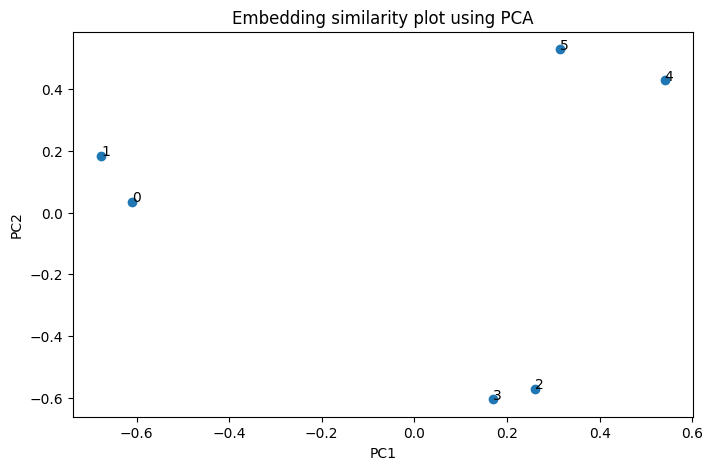

0 Patient has chest pain and breathing difficulty
1 Possible heart attack symptoms
2 Routine diabetes follow up
3 Medication refill appointment
4 Build a Python API using FastAPI
5 Deploy application on Cloud Run


In [13]:
from sklearn.decomposition import PCA

texts = [
    "Patient has chest pain and breathing difficulty",
    "Possible heart attack symptoms",
    "Routine diabetes follow up",
    "Medication refill appointment",
    "Build a Python API using FastAPI",
    "Deploy application on Cloud Run"
]

emb = embedding_model.encode(texts)

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb)

plt.figure(figsize=(8, 5))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
for i, txt in enumerate(texts):
    plt.annotate(str(i), (emb_2d[i, 0], emb_2d[i, 1]))
plt.title("Embedding similarity plot using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

for i, txt in enumerate(texts):
    print(i, txt)

## 9.5 Cosine similarity vs dot similarity

Cosine similarity compares vector direction.

Dot product is affected by both direction and magnitude.

For semantic search, cosine similarity is commonly used.

In [14]:
query = "emergency heart symptoms"
query_emb = embedding_model.encode([query])

scores = cosine_similarity(query_emb, emb)[0]
ranked = sorted(zip(texts, scores), key=lambda x: x[1], reverse=True)

for text, score in ranked:
    print(round(score, 3), "=>", text)

0.78 => Possible heart attack symptoms
0.512 => Patient has chest pain and breathing difficulty
0.072 => Medication refill appointment
0.028 => Routine diabetes follow up
0.015 => Deploy application on Cloud Run
-0.028 => Build a Python API using FastAPI


# Lab 10: Prompt Library

## Goal
Create reusable prompt templates for:

- zero-shot prompting
- few-shot prompting
- system-style instructions
- JSON structured output
- hallucination mitigation

Important: For learning and production, prompts should be reusable and version-controlled.

In [15]:
class PromptLibrary:
    @staticmethod
    def zero_shot(task):
        return f"""
You are a helpful AI assistant.
Task: {task}
Answer clearly and concisely.
""".strip()

    @staticmethod
    def few_shot_sentiment(text):
        return f"""
Classify the sentiment as positive, negative, or neutral.

Example 1:
Text: The service was excellent and fast.
Sentiment: positive

Example 2:
Text: The product broke after one day.
Sentiment: negative

Example 3:
Text: The package arrived yesterday.
Sentiment: neutral

Now classify:
Text: {text}
Sentiment:
""".strip()

    @staticmethod
    def json_output(note):
        return f"""
Extract information from the clinical note.
Return only valid JSON with keys:
- urgency: urgent or non_urgent
- symptoms: list of symptoms
- recommended_action: short action

Clinical note:
{note}
""".strip()

    @staticmethod
    def hallucination_safe(question, context):
        return f"""
Answer the question using only the provided context.
If the answer is not in the context, say: "I don't know based on the provided context."

Context:
{context}

Question:
{question}
""".strip()

print(PromptLibrary.zero_shot("Explain TF-IDF in simple words."))

You are a helpful AI assistant.
Task: Explain TF-IDF in simple words.
Answer clearly and concisely.


## 10.1 Test prompt templates without API

Even before sending prompts to an LLM, you should inspect the final prompt. This reduces mistakes.

In [ ]:
print("Few-shot sentiment prompt:
")
print(PromptLibrary.few_shot_sentiment("The app is useful but sometimes slow."))

print("
" + "="*80 + "
")

print("JSON extraction prompt:
")
print(PromptLibrary.json_output("Patient has chest pain and sweating. ECG required urgently."))

## 10.2 Run prompt templates with Gemini API

In [ ]:
if GEMINI_API_KEY:
    prompt = PromptLibrary.json_output("Patient has chest pain and sweating. ECG required urgently.")
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.1)
    )
    print(response.text)
else:
    print("Skipping API call because API key is missing.")

## 10.3 Hallucination mitigation

Bad prompt:

> Tell me everything about this patient.

Better prompt:

> Use only the given note. If information is missing, say you don't know.

This is very important in clinical, financial, legal, and enterprise applications.

In [ ]:
context = "The patient has mild cough. No fever. Vitals are stable."
question = "Does the patient have chest pain?"

safe_prompt = PromptLibrary.hallucination_safe(question, context)
print(safe_prompt)

# Lab 11: PDF Q&A Bot using RAG

## RAG means Retrieval-Augmented Generation

Normal LLM flow:

```text
User question → LLM → answer
```

RAG flow:

```text
Documents/PDFs → chunks → embeddings → vector database
User question → query embedding → top-k chunks → LLM → grounded answer
```

Why RAG matters:

- Reduces hallucination
- Uses your private/company documents
- Avoids retraining the whole model
- Gives source-grounded answers

## 11.1 Create sample document text

In real life, this text comes from PDFs. For now, we create sample text so the notebook runs immediately.

In [ ]:
sample_document = """
Large Language Models are AI systems trained on massive text datasets. They generate text by predicting the next token.
Tokens are pieces of text such as words, subwords, punctuation, or symbols.
Temperature controls randomness in generation. Low temperature gives focused answers. High temperature gives creative answers.
RAG stands for Retrieval-Augmented Generation. It retrieves relevant chunks from documents and gives them to the LLM as context.
Embeddings convert text into numeric vectors. Similar text has vectors close together.
Cosine similarity is commonly used to compare embedding vectors.
FAISS is a vector search library used for fast similarity search.
Cloud Run is a serverless GCP service used to deploy APIs and applications.
Vertex AI is Google Cloud's machine learning platform for building and using AI models.
"""

print(sample_document)

## 11.2 Text chunking

Chunking splits long documents into smaller pieces.

Good chunks should:

- be small enough for retrieval
- contain enough context
- optionally overlap with neighboring chunks

Common chunk sizes:

- 300–500 tokens for small QA
- 800–1200 tokens for detailed enterprise docs

In [ ]:
def chunk_text(text, chunk_size=220, overlap=40):
    text = re.sub(r"\s+", " ", text).strip()
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start = end - overlap
        if start < 0:
            start = 0
        if start >= len(text):
            break
    return chunks

chunks = chunk_text(sample_document, chunk_size=180, overlap=30)

for i, chunk in enumerate(chunks):
    print(f"Chunk {i}: {chunk}
")

## 11.3 Build FAISS vector index

In [ ]:
import faiss

chunk_embeddings = embedding_model.encode(chunks).astype("float32")

# Normalize vectors for cosine-like search using inner product
faiss.normalize_L2(chunk_embeddings)

dimension = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(chunk_embeddings)

print("Number of chunks in FAISS index:", index.ntotal)

## 11.4 Retrieve top-k chunks

In [ ]:
def retrieve(query, top_k=3):
    query_embedding = embedding_model.encode([query]).astype("float32")
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "score": float(score),
            "chunk": chunks[idx]
        })
    return results

query = "What is RAG and why is it useful?"
results = retrieve(query)

for r in results:
    print("Score:", round(r["score"], 3))
    print(r["chunk"])
    print("-"*80)

## 11.5 Generate answer using retrieved context

This step sends the retrieved chunks to the LLM.

If no API key is available, the notebook will print the final prompt so you can understand the flow.

In [ ]:
def build_rag_prompt(question, retrieved_chunks):
    context = "

".join([item["chunk"] for item in retrieved_chunks])
    return f"""
You are a helpful AI assistant.
Answer the question using only the context below.
If the answer is not in the context, say you don't know based on the provided context.

Context:
{context}

Question:
{question}

Answer:
""".strip()

question = "What is RAG?"
retrieved = retrieve(question, top_k=3)
rag_prompt = build_rag_prompt(question, retrieved)

print(rag_prompt)

In [ ]:
if GEMINI_API_KEY:
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=rag_prompt,
        config=types.GenerateContentConfig(temperature=0.1)
    )
    print(response.text)
else:
    print("Skipping API call because API key is missing. Above prompt shows the full RAG input.")

## 11.6 Read real PDF files

Use this when you have a real PDF.

In Colab:

```python
from google.colab import files
uploaded = files.upload()
```

Then read it with `pypdf`.

In [ ]:
# Example PDF reader function
# Uncomment and use when you have a PDF file path.

# from pypdf import PdfReader
#
# def read_pdf(path):
#     reader = PdfReader(path)
#     text = ""
#     for page in reader.pages:
#         page_text = page.extract_text() or ""
#         text += page_text + "
"
#     return text
#
# pdf_text = read_pdf("your_file.pdf")
# chunks = chunk_text(pdf_text, chunk_size=800, overlap=100)
# print("PDF chunks:", len(chunks))

# Final Project: End-to-end PDF Q&A Bot Architecture

## Production architecture on GCP

```text
User
 ↓
Frontend / API
 ↓
Cloud Run FastAPI service
 ↓
Cloud Storage PDFs
 ↓
Document chunking
 ↓
Embedding model
 ↓
Vector DB / FAISS / Vertex AI Vector Search
 ↓
Top-k retrieved context
 ↓
Gemini model on Vertex AI
 ↓
Grounded answer
```

## What to learn next

1. Gemini API in VS Code
2. Prompt engineering
3. Embeddings
4. FAISS/ChromaDB
5. RAG evaluation
6. FastAPI
7. Docker
8. Cloud Run deployment
9. Vertex AI production authentication

## Interview explanation

A strong interview answer:

> I built a RAG-based PDF Q&A bot. First, I extracted text from PDFs, chunked the text with overlap, generated embeddings for every chunk, and stored those vectors in a FAISS index. For each user question, I generated a query embedding, retrieved the top-k most similar chunks using cosine similarity, and passed those chunks as context to Gemini. I used prompt constraints to reduce hallucination and asked the model to answer only from the retrieved context.

# Practice Tasks

Try these after completing the notebook:

1. Add 20 more clinical notes to Lab 8 and retrain the classifier.
2. Compare TF-IDF Logistic Regression vs embedding similarity classification.
3. Add a prompt template for SQL generation.
4. Build a RAG bot on your own PDF.
5. Deploy the RAG bot using FastAPI.
6. Move from API key to Vertex AI ADC authentication on GCP.